## IMPORT LIBRARY

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## MEMBACA GAMBAR

In [2]:
img = cv2.imread('aset1.jpg')

In [3]:
img.shape

(1756, 4159, 3)

## KONVERSI  CITRA BGR to RGB

In [4]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## MEMISAHKAN CHANNEL

In [5]:
B = rgb[:, :, 2]
G = rgb[:, :, 1]
R = rgb[:, :, 0]

## MENAMPILKAN HASIL

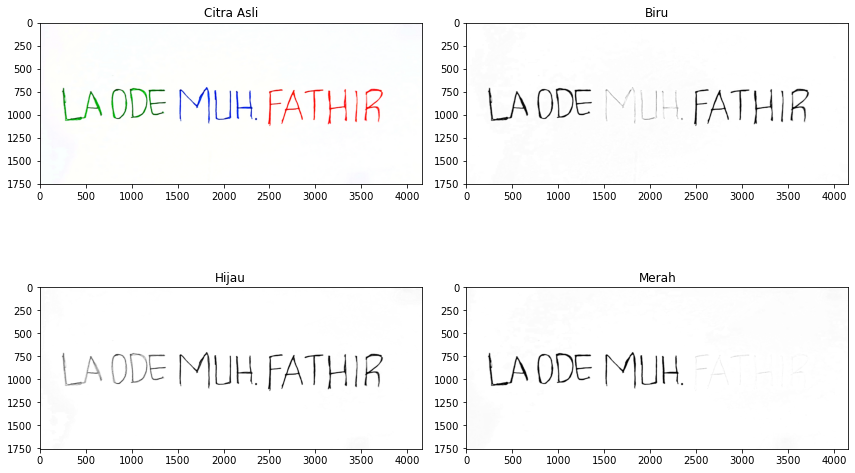

In [6]:
plt.figure(figsize=(12,8))

# Citra Asli
plt.subplot(2,2,1)
plt.imshow(rgb)
plt.title("Citra Asli")

# Biru
plt.subplot(2,2,2)
plt.imshow(B, cmap='gray')
plt.title("Biru")

# Hijau
plt.subplot(2,2,3)
plt.imshow(G, cmap='gray')
plt.title("Hijau")

# Merah
plt.subplot(2,2,4)
plt.imshow(R, cmap='gray')
plt.title("Merah")

plt.tight_layout()
plt.show()

## MENAMPILKAN HISTOGRAM

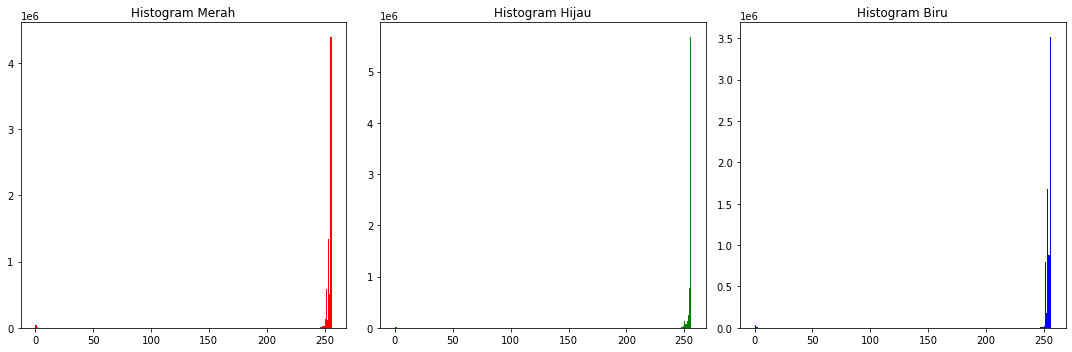

In [7]:
plt.figure(figsize=(15, 5))

# Histogram Merah
plt.subplot(1, 3, 1)
plt.hist(R.ravel(), 256, [0, 256], color='red')
plt.title("Histogram Merah")

# Histogram Hijau
plt.subplot(1, 3, 2)
plt.hist(G.ravel(), 256, [0, 256], color='green')
plt.title("Histogram Hijau")

# Histogram Biru
plt.subplot(1, 3, 3)
plt.hist(B.ravel(), 256, [0, 256], color='blue')
plt.title("Histogram Biru")


plt.tight_layout()
plt.show()

## Konversi ke HSV

In [8]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

## THRESHOLDING

In [9]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
none_thresh = np.zeros_like(gray)

## DETEKSI SEMUA WARNA BIRU

In [10]:
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])

blue_thresh = cv2.inRange(hsv, lower_blue, upper_blue)

## DETEKSI SEMUA WARNA MERAH

In [11]:
lower_red = np.array([0, 50, 50])
upper_red = np.array([10, 255, 255])

red_thresh = cv2.inRange(hsv, lower_red, upper_red)

## DETEKSI SEMUA WARNA MERAH

In [12]:
red_blue_thresh = cv2.bitwise_or(red_thresh, blue_thresh)

## DETEKSI SEMUA WARNA

In [13]:
rgb_thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)[1]

## MENAMPILKAN HASIL

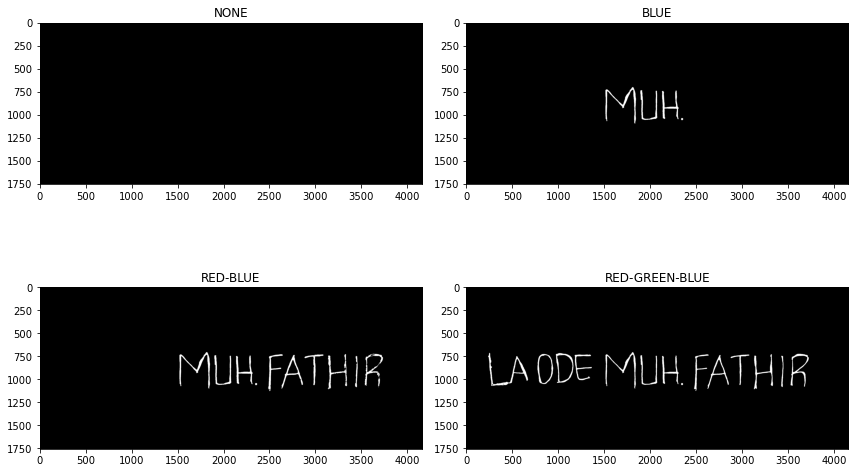

In [14]:
plt.figure(figsize=(12,8))

# NONE
plt.subplot(2,2,1)
plt.imshow(none_thresh, cmap='gray')
plt.title("NONE")

# BLUE
plt.subplot(2,2,2)
plt.imshow(blue_thresh, cmap='gray')
plt.title("BLUE")

# RED-BLUE
plt.subplot(2,2,3)
plt.imshow(red_blue_thresh, cmap='gray')
plt.title("RED-BLUE")

# RED-GREEN-BLUE
plt.subplot(2,2,4)
plt.imshow(rgb_thresh, cmap='gray')
plt.title("RED-GREEN-BLUE")

plt.tight_layout()
plt.show()